In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("All imports done")

2026-03-28 06:03:07.869209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774677788.107907      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774677788.170560      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774677788.705697      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774677788.705737      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774677788.705739      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
All imports done


In [4]:
start_load = time.time()

interaction_data  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv')
presentations     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv')
presentations_df  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv')
ratings_matrix    = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv')
recommendations   = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv')
user_profiles     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv')

print(f"Loaded in {time.time()-start_load:.2f}s")
print(f"interaction_data : {interaction_data.shape}")
print(f"ratings_matrix   : {ratings_matrix.shape}")
print(f"recommendations  : {recommendations.shape}")
print(f"user_profiles    : {user_profiles.shape}")
print(f"presentations    : {presentations.shape}")

Loaded in 0.21s
interaction_data : (25000, 75)
ratings_matrix   : (3000, 5)
recommendations  : (100, 26)
user_profiles    : (30, 5)
presentations    : (78, 15)


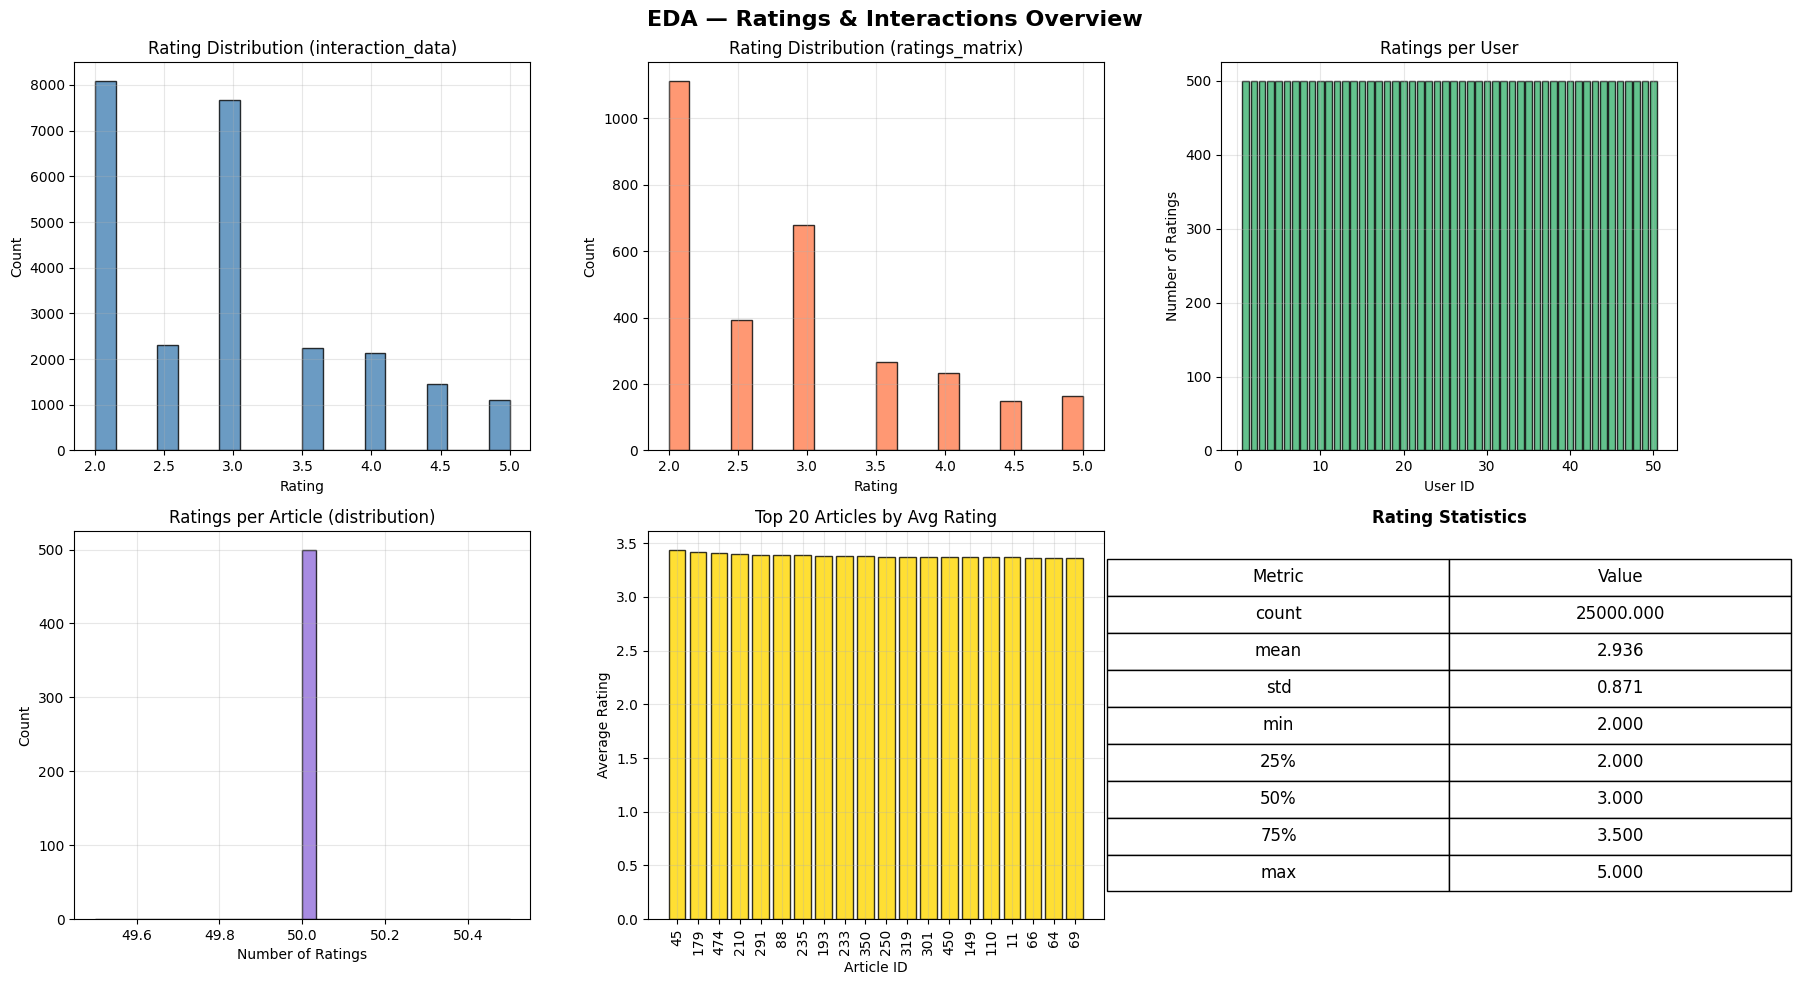


Unique users    : 50
Unique articles : 500
Total ratings   : 25000
Rating range    : 2.0 → 5.0
Sparsity        : 0.0000


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Ratings & Interactions Overview', fontsize=16, fontweight='bold')

# 1. Rating distribution — interaction_data
axes[0,0].hist(interaction_data['rating'], bins=20,
               color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Rating Distribution (interaction_data)')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, alpha=0.3)

# 2. Rating distribution — ratings_matrix
axes[0,1].hist(ratings_matrix['rating'], bins=20,
               color='coral', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Rating Distribution (ratings_matrix)')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(True, alpha=0.3)

# 3. Ratings per user
ratings_per_user = interaction_data.groupby('user_id')['rating'].count()
axes[0,2].bar(ratings_per_user.index, ratings_per_user.values,
              color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0,2].set_title('Ratings per User')
axes[0,2].set_xlabel('User ID')
axes[0,2].set_ylabel('Number of Ratings')
axes[0,2].grid(True, alpha=0.3)

# 4. Ratings per article
ratings_per_article = interaction_data.groupby('article_id')['rating'].count()
axes[1,0].hist(ratings_per_article.values, bins=30,
               color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Ratings per Article (distribution)')
axes[1,0].set_xlabel('Number of Ratings')
axes[1,0].set_ylabel('Count')
axes[1,0].grid(True, alpha=0.3)

# 5. Average rating per article (top 20)
avg_per_article = interaction_data.groupby('article_id')['rating'].mean().sort_values(ascending=False).head(20)
axes[1,1].bar(avg_per_article.index.astype(str), avg_per_article.values,
              color='gold', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Top 20 Articles by Avg Rating')
axes[1,1].set_xlabel('Article ID')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].grid(True, alpha=0.3)

# 6. Rating stats summary
stats = interaction_data['rating'].describe()
axes[1,2].axis('off')
table_data = [[k, f"{v:.3f}"] for k, v in stats.items()]
table = axes[1,2].table(cellText=table_data,
                         colLabels=['Metric', 'Value'],
                         loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)
axes[1,2].set_title('Rating Statistics', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nUnique users    : {interaction_data['user_id'].nunique()}")
print(f"Unique articles : {interaction_data['article_id'].nunique()}")
print(f"Total ratings   : {len(interaction_data)}")
print(f"Rating range    : {interaction_data['rating'].min()} → {interaction_data['rating'].max()}")
print(f"Sparsity        : {1 - len(ratings_matrix)/(ratings_matrix['user_id'].nunique()*ratings_matrix['article_id'].nunique()):.4f}")

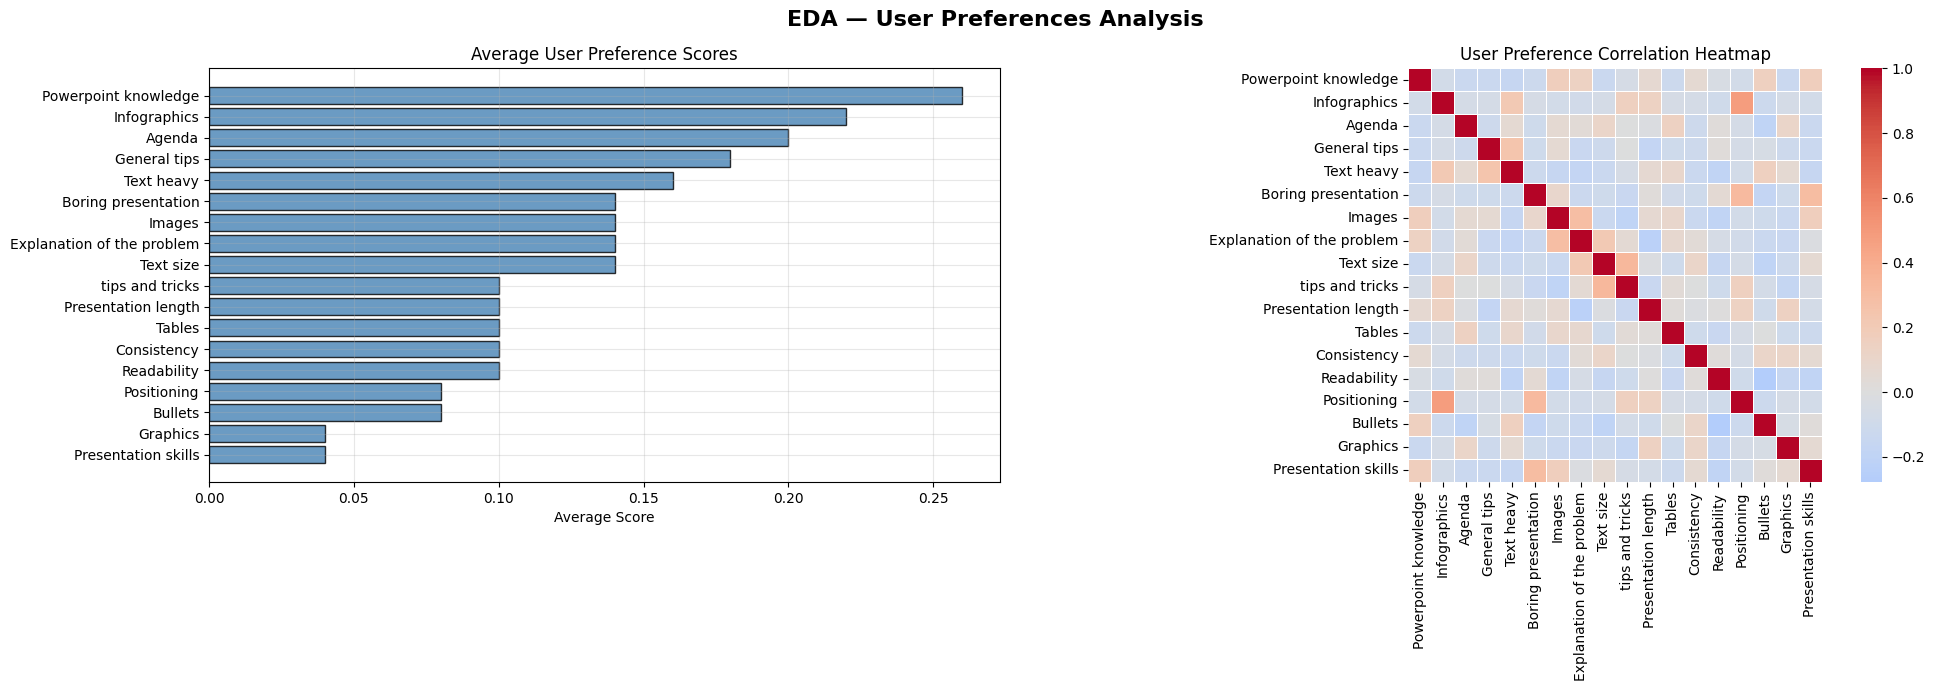

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# User preference columns
pref_cols = [c for c in interaction_data.columns if c.startswith('user_preference_')]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('EDA — User Preferences Analysis', fontsize=16, fontweight='bold')

# ---- 1. Average preference scores ----
avg_prefs = interaction_data[pref_cols].mean().sort_values(ascending=False)
clean_labels = [c.replace('user_preference_', '') for c in avg_prefs.index]

axes[0].barh(clean_labels, avg_prefs.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Average User Preference Scores')
axes[0].set_xlabel('Average Score')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

# ---- 2. FULL Correlation heatmap (no masking) ----
pref_corr = interaction_data[pref_cols].corr()

sns.heatmap(pref_corr,
            ax=axes[1],
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            xticklabels=clean_labels,
            yticklabels=clean_labels,
            annot=False)

axes[1].set_title('User Preference Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [8]:
# Check if you already have a merged dataframe
# Based on your EDA output, your merged df has 83 columns
# Let's recreate it properly

df_merged = interaction_data.copy()

# Merge user_profiles
df_merged = df_merged.merge(
    user_profiles[['user_id', 'type', 'location',
                   'preferences', 'preferred_presentation_type']],
    on='user_id',
    how='left',
    suffixes=('', '_user')
)

# Merge recommendations (article-level info)
df_merged = df_merged.merge(
    recommendations[['article_id', 'presentation_type',
                      'audience_type', 'Main issue', 'popularity']],
    on='article_id',
    how='left',
    suffixes=('', '_rec')
)

print(f"Merged shape: {df_merged.shape}")
print(f"\nConfirm columns exist:")
print(f"  preferred_presentation_type : {'preferred_presentation_type' in df_merged.columns}")
print(f"  audience_type               : {'audience_type' in df_merged.columns}")
print(f"  presentation_type           : {'presentation_type' in df_merged.columns}")

Merged shape: (25000, 83)

Confirm columns exist:
  preferred_presentation_type : True
  audience_type               : True
  presentation_type           : True


=== CHECKING DATAFRAMES ===

interaction_data shape  : (25000, 75)
user_profiles shape     : (30, 5)
recommendations shape   : (100, 26)

df_merged shape         : (25000, 83)
df_merged columns       : ['user_id', 'article_id', 'rating', 'timestamp', 'location', 'user_preference_Boring presentation', 'user_preference_Graphics', 'user_preference_Readability', 'user_preference_Consistency', 'user_preference_Images', 'user_preference_Bullets', 'user_preference_Text size', 'user_preference_Text heavy', 'user_preference_Tables', 'user_preference_Agenda', 'user_preference_Infographics', 'user_preference_Positioning', 'user_preference_Presentation length', 'user_preference_General tips', 'user_preference_Presentation skills', 'user_preference_Powerpoint knowledge', 'user_preference_tips and tricks', 'user_preference_Explanation of the problem', 'user_type_business', 'user_type_teacher', 'user_type_student', 'user_type_researcher', 'user_type_manager', 'user_type_technical', 'user_type_special

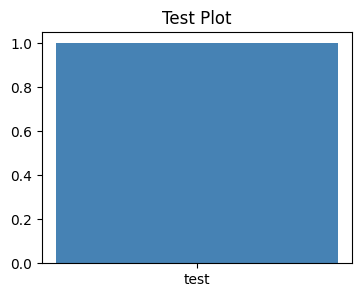


If you see a bar chart above, matplotlib is working fine


In [9]:
# ── DIAGNOSTIC: Run this and paste the output ─────────────

print("=== CHECKING DATAFRAMES ===")
print(f"\ninteraction_data shape  : {interaction_data.shape}")
print(f"user_profiles shape     : {user_profiles.shape}")
print(f"recommendations shape   : {recommendations.shape}")

# Check if df_merged exists
try:
    print(f"\ndf_merged shape         : {df_merged.shape}")
    print(f"df_merged columns       : {df_merged.columns.tolist()}")
except NameError:
    print("\ndf_merged does NOT exist — you skipped the Fix cell")

# Check what columns interaction_data actually has
print("\n=== INTERACTION_DATA COLUMNS ===")
for col in interaction_data.columns.tolist():
    print(f"  {col}")

# Check user_profiles columns
print("\n=== USER_PROFILES COLUMNS ===")
for col in user_profiles.columns.tolist():
    print(f"  {col}")

# Check recommendations columns
print("\n=== RECOMMENDATIONS COLUMNS ===")
for col in recommendations.columns.tolist():
    print(f"  {col}")

# Check if matplotlib is working at all
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.bar(['test'], [1], color='steelblue')
ax.set_title('Test Plot')
plt.show()
print("\nIf you see a bar chart above, matplotlib is working fine")

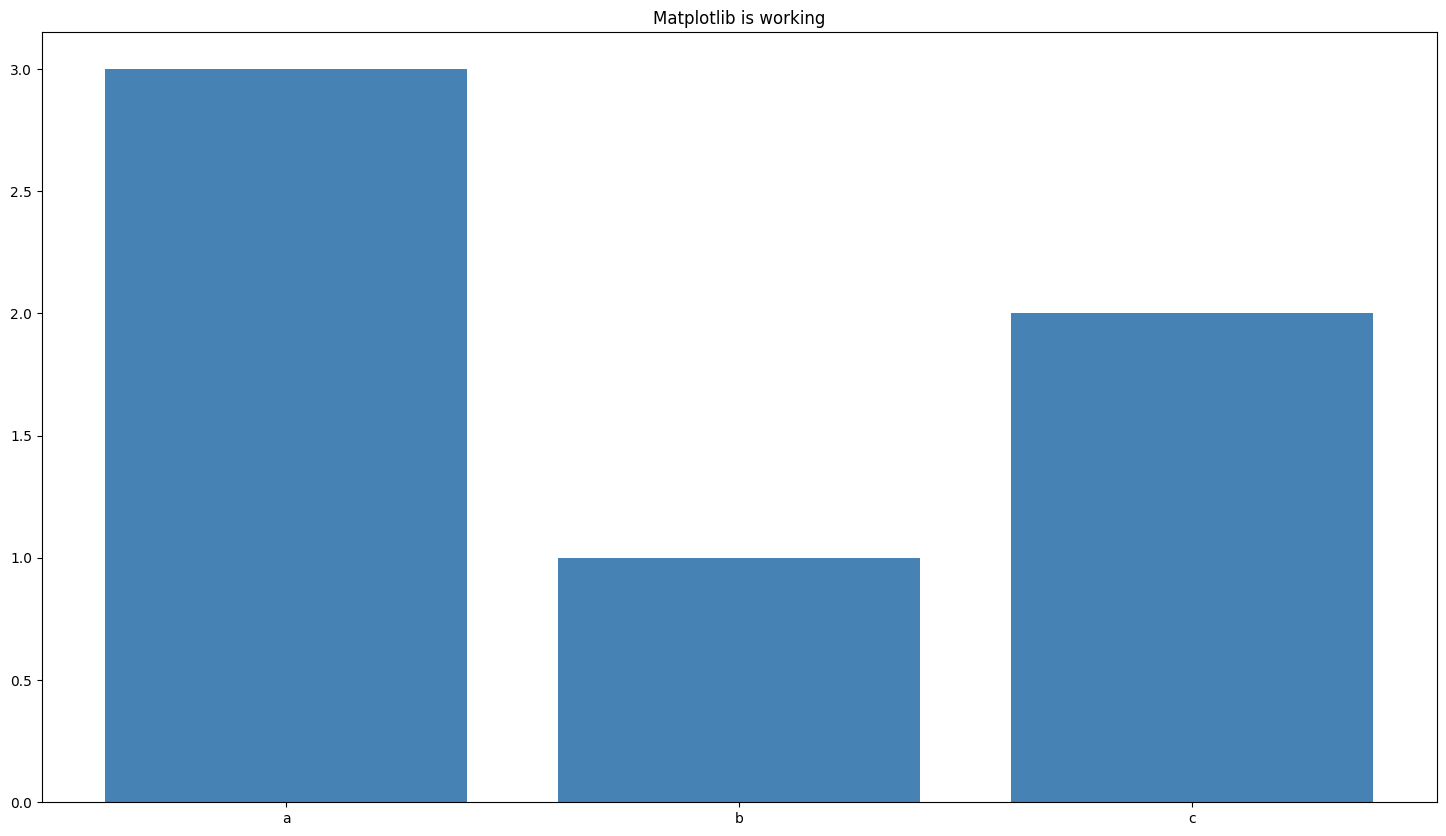

If you see the bar chart, you are good to go


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (18, 10)
matplotlib.rcParams['figure.dpi']     = 100

# Quick test
fig, ax = plt.subplots()
ax.bar(['a','b','c'], [3,1,2], color='steelblue')
ax.set_title('Matplotlib is working')
plt.show()
print("If you see the bar chart, you are good to go")

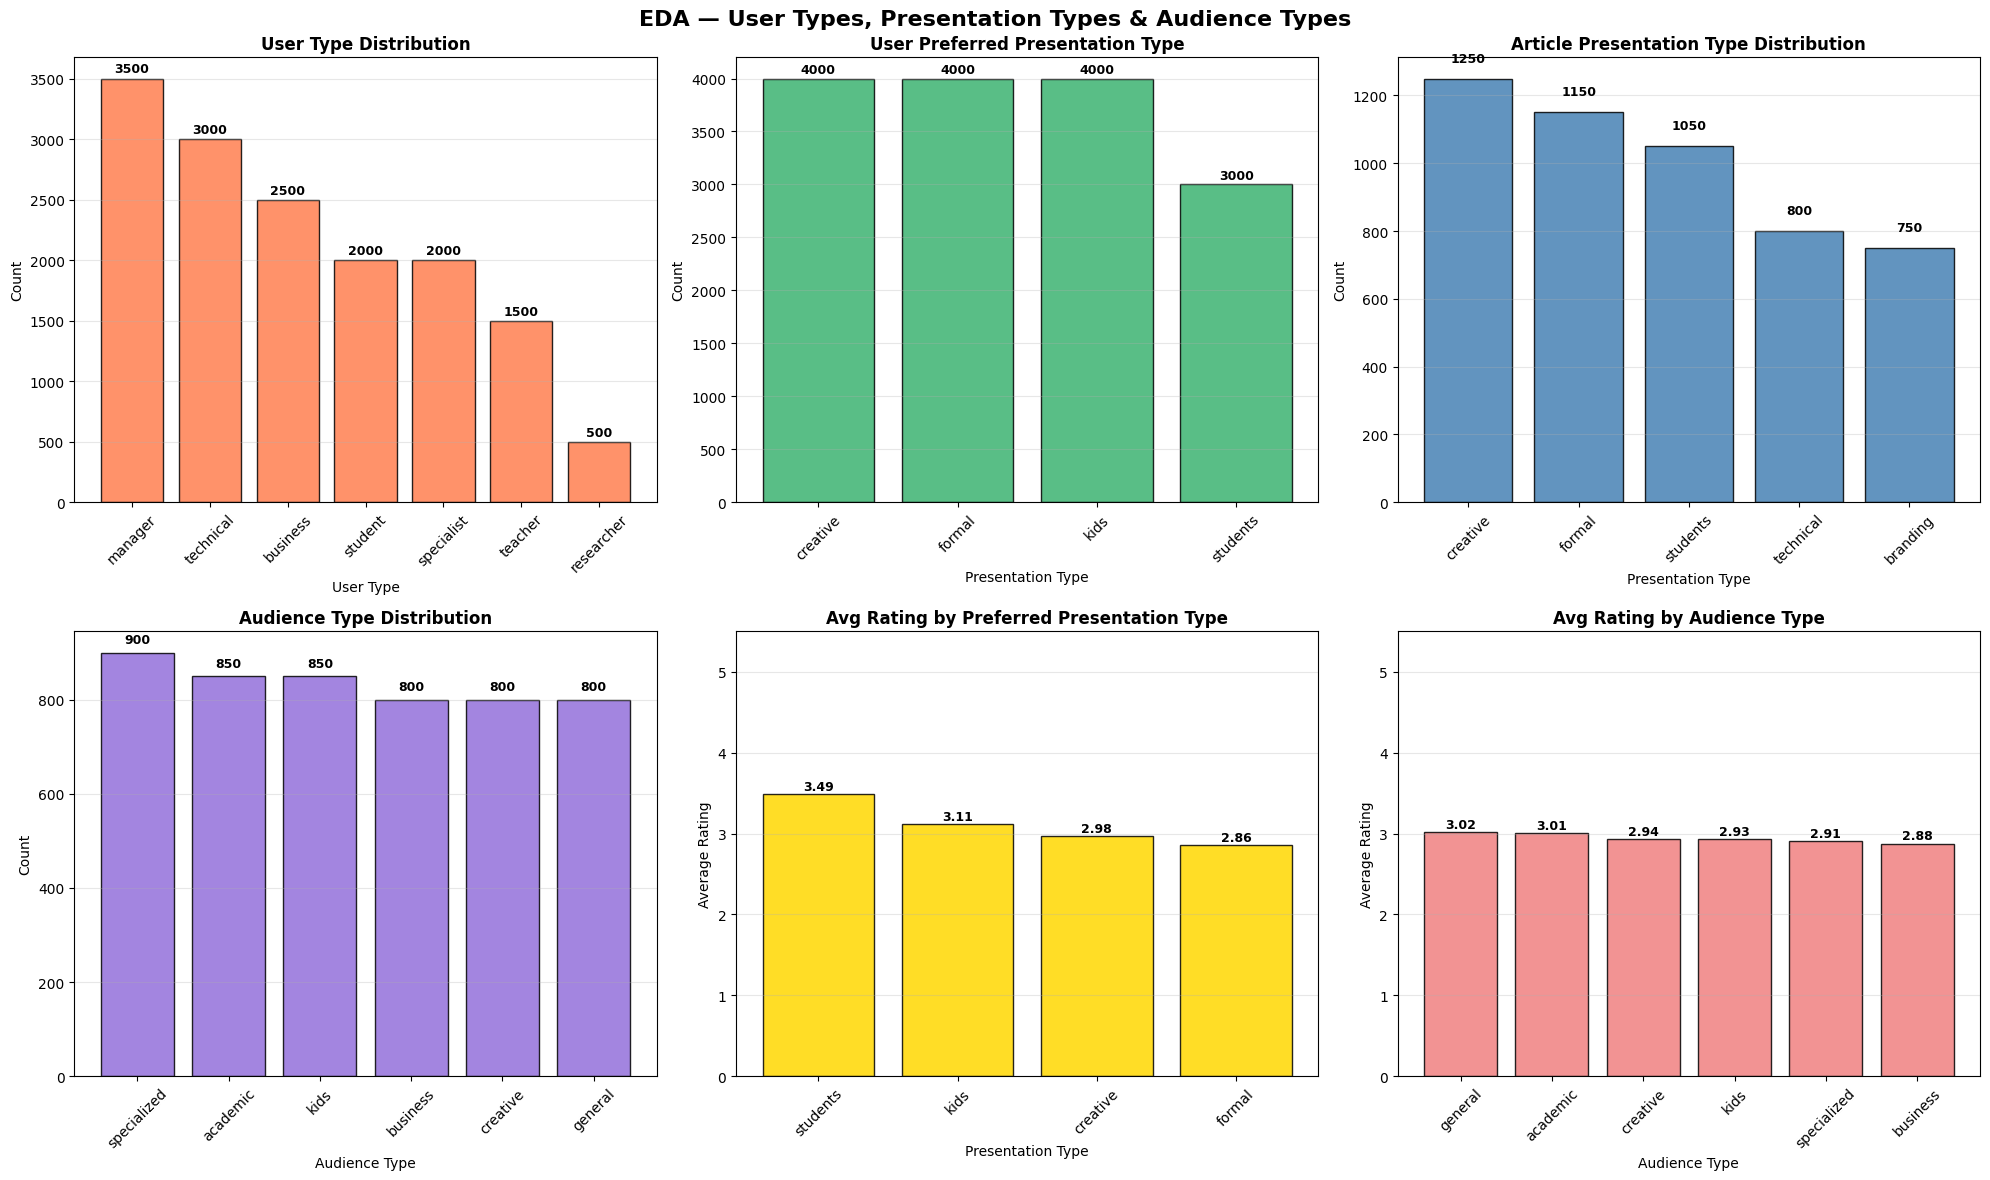


User Type Counts:
type
manager       3500
technical     3000
business      2500
student       2000
specialist    2000
teacher       1500
researcher     500

Preferred Presentation Type Counts:
preferred_presentation_type
creative    4000
formal      4000
kids        4000
students    3000

Article Presentation Type Counts:
presentation_type
creative     1250
formal       1150
students     1050
technical     800
branding      750

Audience Type Counts:
audience_type
specialized    900
academic       850
kids           850
business       800
creative       800
general        800


In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('EDA — User Types, Presentation Types & Audience Types',
             fontsize=16, fontweight='bold')

# ── Plot 1: User Types (from string column in df_merged) ─
user_type_counts = df_merged['type'].value_counts()

bars1 = axes[0,0].bar(user_type_counts.index, user_type_counts.values,
                       color='coral', edgecolor='black', alpha=0.85)
axes[0,0].set_title('User Type Distribution', fontweight='bold')
axes[0,0].set_xlabel('User Type')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, user_type_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: User Preferred Presentation Type ─────────────
pref_ptype = df_merged['preferred_presentation_type'].value_counts()

bars2 = axes[0,1].bar(pref_ptype.index, pref_ptype.values,
                       color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[0,1].set_title('User Preferred Presentation Type', fontweight='bold')
axes[0,1].set_xlabel('Presentation Type')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, pref_ptype.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 3: Article Presentation Type ────────────────────
# Use the string column from recommendations merge
art_ptype = df_merged['presentation_type'].value_counts()

bars3 = axes[0,2].bar(art_ptype.index, art_ptype.values,
                       color='steelblue', edgecolor='black', alpha=0.85)
axes[0,2].set_title('Article Presentation Type Distribution', fontweight='bold')
axes[0,2].set_xlabel('Presentation Type')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, art_ptype.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 4: Audience Type Distribution ───────────────────
# Use string column, NOT one-hot columns (those are all zeros)
aud_counts = df_merged['audience_type'].value_counts()

bars4 = axes[1,0].bar(aud_counts.index, aud_counts.values,
                       color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Audience Type Distribution', fontweight='bold')
axes[1,0].set_xlabel('Audience Type')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, aud_counts.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 20,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 5: Avg Rating by Preferred Presentation Type ────
avg_by_ptype = (df_merged
                .groupby('preferred_presentation_type')['rating']
                .mean()
                .sort_values(ascending=False))

bars5 = axes[1,1].bar(avg_by_ptype.index, avg_by_ptype.values,
                       color='gold', edgecolor='black', alpha=0.85)
axes[1,1].set_title('Avg Rating by Preferred Presentation Type',
                     fontweight='bold')
axes[1,1].set_xlabel('Presentation Type')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].set_ylim(0, 5.5)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, avg_by_ptype.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# ── Plot 6: Avg Rating by Audience Type ──────────────────
avg_by_aud = (df_merged
              .groupby('audience_type')['rating']
              .mean()
              .sort_values(ascending=False))

bars6 = axes[1,2].bar(avg_by_aud.index, avg_by_aud.values,
                       color='lightcoral', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Avg Rating by Audience Type', fontweight='bold')
axes[1,2].set_xlabel('Audience Type')
axes[1,2].set_ylabel('Average Rating')
axes[1,2].set_ylim(0, 5.5)
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars6, avg_by_aud.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_user_presentation_types.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print the actual values ───────────────────────────────
print("\nUser Type Counts:")
print(user_type_counts.to_string())
print("\nPreferred Presentation Type Counts:")
print(pref_ptype.to_string())
print("\nArticle Presentation Type Counts:")
print(art_ptype.to_string())
print("\nAudience Type Counts:")
print(aud_counts.to_string())

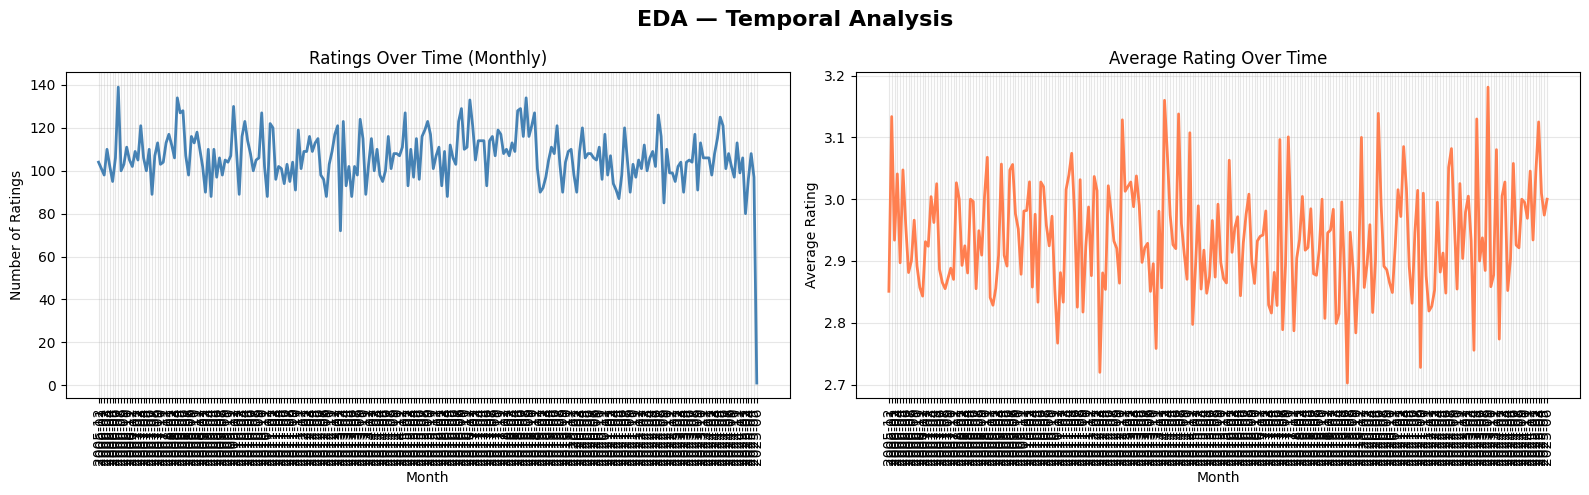

In [12]:
interaction_data['timestamp'] = pd.to_datetime(interaction_data['timestamp'])
ratings_matrix['timestamp']   = pd.to_datetime(ratings_matrix['timestamp'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('EDA — Temporal Analysis', fontsize=16, fontweight='bold')

# Ratings over time
interaction_data['year_month'] = interaction_data['timestamp'].dt.to_period('M')
monthly_counts = interaction_data.groupby('year_month').size()
axes[0].plot(monthly_counts.index.astype(str), monthly_counts.values,
             color='steelblue', linewidth=2)
axes[0].set_title('Ratings Over Time (Monthly)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Ratings')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, alpha=0.3)

# Average rating over time
monthly_avg = interaction_data.groupby('year_month')['rating'].mean()
axes[1].plot(monthly_avg.index.astype(str), monthly_avg.values,
             color='coral', linewidth=2)
axes[1].set_title('Average Rating Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print("Starting Feature Engineering...")

df = interaction_data.copy()

# ── 1. Timestamp features ─────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month']     = df['timestamp'].dt.month

# Cyclic encoding (matches paper's sinusoidal approach)
df['hour_sin']  = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']      / 24)
df['day_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['day_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month']     / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']     / 12)

# Days since first interaction per user
df = df.sort_values('timestamp')
first_ts = df.groupby('user_id')['timestamp'].transform('min')
df['days_since_first'] = (df['timestamp'] - first_ts).dt.days

# ── 2. User activity features ─────────────────────────────
user_stats = df.groupby('user_id').agg(
    user_avg_rating    = ('rating', 'mean'),
    user_rating_count  = ('rating', 'count'),
    user_rating_std    = ('rating', 'std')
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)
df = df.merge(user_stats, on='user_id', how='left')

# ── 3. Item activity features ─────────────────────────────
item_stats = df.groupby('article_id').agg(
    item_avg_rating   = ('rating', 'mean'),
    item_rating_count = ('rating', 'count'),
    item_rating_std   = ('rating', 'std')
).reset_index()
item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0)
df = df.merge(item_stats, on='article_id', how='left')

# ── 4. User-item match score ──────────────────────────────
pref_cols  = [c for c in df.columns if c.startswith('user_preference_')]
issue_cols = ['Boring presentation','Graphics','Readability','Consistency',
              'Images','Bullets','Text size','Text heavy','Tables',
              'Agenda','Infographics','Positioning']

# How many issues match user preferences
def compute_match(row):
    score = 0
    for p, i in zip(pref_cols, issue_cols):
        if i in row.index:
            score += int(row[p] == row[i])
    return score

tqdm.pandas(desc="Computing match scores")
df['preference_match_score'] = df.progress_apply(compute_match, axis=1)

# ── 5. Exponential decay weight (paper's approach) ────────
decay_rate = 0.01
df['time_decay_weight'] = np.exp(-decay_rate * df['days_since_first'])

# ── 6. Normalize continuous features ─────────────────────
scaler = MinMaxScaler()
cols_to_scale = ['days_since_first','user_avg_rating','user_rating_count',
                 'user_rating_std','item_avg_rating','item_rating_count',
                 'item_rating_std','preference_match_score','time_decay_weight']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Feature engineering done. Final shape: {df.shape}")
print(f"New columns added: {df.shape[1] - interaction_data.shape[1]}")
df.head(3)

Starting Feature Engineering...


Computing match scores: 100%|██████████| 25000/25000 [00:01<00:00, 17265.86it/s]


Feature engineering done. Final shape: (25000, 94)
New columns added: 18


,user_id,article_id,rating,timestamp,location,user_preference_Boring presentation,user_preference_Graphics,user_preference_Readability,user_preference_Consistency,user_preference_Images,...,month_cos,days_since_first,user_avg_rating,user_rating_count,user_rating_std,item_avg_rating,item_rating_count,item_rating_std,preference_match_score,time_decay_weight
0,13,114,3.0,2005-12-01 07:00:00,Florida,0,0,0,0,0,...,1.0,0.0,0.437714,0.0,0.902715,0.000000,0.0,0.086354,0.500000,1.0
1,14,474,2.5,2005-12-01 12:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.232717,0.0,0.838889,0.960000,0.0,0.957237,0.416667,1.0
2,17,449,4.5,2005-12-01 17:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.107118,0.0,0.980352,0.866667,0.0,0.532169,0.333333,1.0


In [14]:
print("="*60)
print("MODEL 3: REINFORCEMENT LEARNING (DQN)")
print("="*60)

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from collections import deque
import random
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
import json
import os
from datetime import timedelta
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

os.makedirs('saved_models', exist_ok=True)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found — running on CPU")

USER_FEAT_COLS = [
    'user_preference_Boring presentation','user_preference_Graphics',
    'user_preference_Readability','user_preference_Consistency',
    'user_preference_Images','user_preference_Bullets',
    'user_preference_Text size','user_preference_Text heavy',
    'user_preference_Tables','user_preference_Agenda',
    'user_preference_Infographics','user_preference_Positioning',
    'user_preference_Presentation length','user_preference_General tips',
    'user_preference_Presentation skills','user_preference_Powerpoint knowledge',
    'user_preference_tips and tricks','user_preference_Explanation of the problem',
    'user_type_business','user_type_teacher','user_type_student',
    'user_type_researcher','user_type_manager','user_type_technical',
    'user_type_specialist',
    'presentation_type_formal_x','presentation_type_creative_x',
    'presentation_type_business_x','presentation_type_educational_x',
    'presentation_type_technical_x','presentation_type_persuasive_x'
]

ITEM_FEAT_COLS = [
    'Boring presentation','Graphics','Readability','Consistency',
    'Images','Bullets','Text size','Text heavy','Tables','Agenda',
    'Infographics','Positioning','Presentation length','General tips',
    'Presentation skills','Powerpoint knowledge','tips and tricks',
    'Explanation of the problem',
    'presentation_type_formal_y','presentation_type_creative_y',
    'presentation_type_business_y','presentation_type_educational_y',
    'presentation_type_technical_y','presentation_type_persuasive_y',
    'audience_type_academic','audience_type_business','audience_type_technical',
    'audience_type_kids','audience_type_general'
]

# Only keep columns that actually exist
USER_FEAT_COLS = [c for c in USER_FEAT_COLS if c in interaction_data.columns]
ITEM_FEAT_COLS = [c for c in ITEM_FEAT_COLS if c in interaction_data.columns]

print(f"User feature dim : {len(USER_FEAT_COLS)}")
print(f"Item feature dim : {len(ITEM_FEAT_COLS)}")

MODEL 3: REINFORCEMENT LEARNING (DQN)
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
User feature dim : 31
Item feature dim : 29


In [15]:
df_dqn = interaction_data.copy()

keep_cols = ['user_id','article_id','rating'] + USER_FEAT_COLS + ITEM_FEAT_COLS
keep_cols = [c for c in keep_cols if c in df_dqn.columns]
df_dqn    = df_dqn[keep_cols].dropna()

# Fill any missing item cols with 0
for c in ITEM_FEAT_COLS:
    if c not in df_dqn.columns:
        df_dqn[c] = 0

# Build article feature lookup table
article_features_dqn = (df_dqn.groupby('article_id')[ITEM_FEAT_COLS]
                         .first().reset_index())
article_ids          = article_features_dqn['article_id'].values
n_actions            = len(article_ids)
article_feat_matrix  = article_features_dqn[ITEM_FEAT_COLS].values.astype(np.float32)

# Map article_id to index
art2idx              = {aid: i for i, aid in enumerate(article_ids)}
df_dqn['article_idx'] = df_dqn['article_id'].map(art2idx)

STATE_DIM  = len(USER_FEAT_COLS) + len(ITEM_FEAT_COLS)
ACTION_DIM = n_actions

# 70 / 15 / 15 split
train_dqn, temp_dqn = train_test_split(df_dqn, test_size=0.30, random_state=42)
val_dqn,   test_dqn = train_test_split(temp_dqn, test_size=0.50, random_state=42)

print(f"Train : {len(train_dqn)} | Val : {len(val_dqn)} | Test : {len(test_dqn)}")
print(f"State dim  : {STATE_DIM}")
print(f"Action dim : {ACTION_DIM}")
print(f"Articles   : {n_actions}")

Train : 17500 | Val : 3750 | Test : 3750
State dim  : 60
Action dim : 500
Articles   : 500


In [16]:
def build_dqn(state_dim, action_dim,
              units=[256, 128], lr=1e-3):
    """
    DQN network matching paper architecture:
    256 neurons → 128 neurons → output (Q-value per article)
    """
    inp = Input(shape=(state_dim,), name='state')
    x   = inp

    for i, u in enumerate(units):
        x = layers.Dense(u, activation='relu',
                          name=f'dense_{i}')(x)
        x = layers.BatchNormalization(name=f'bn_{i}')(x)
        x = layers.Dropout(0.2, name=f'drop_{i}')(x)

    out = layers.Dense(action_dim, activation='linear',
                       name='q_values')(x)

    model = Model(inp, out, name='DQN')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mse'
    )
    return model

dqn_model        = build_dqn(STATE_DIM, ACTION_DIM)
dqn_target_model = build_dqn(STATE_DIM, ACTION_DIM)
dqn_target_model.set_weights(dqn_model.get_weights())

dqn_model.summary()
print(f"\nModel parameters: {dqn_model.count_params():,}")

I0000 00:00:1774677982.483912      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774677982.490084      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 256)            │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 500)            │        64,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,548 (447.45 KB)

 Trainable params: 113,780 (444.45 KB)

 Non-trainable params: 768 (3.00 KB)


Model parameters: 114,548


In [18]:
# ── Hyperparameters ───────────────────────────────────────
GAMMA         = 0.95
EPSILON       = 1.0
EPSILON_MIN   = 0.05
EPSILON_DECAY = 0.995
BATCH_SIZE    = 128
TARGET_UPDATE = 100
EPISODES      = 3
REPLAY_SIZE   = 2000          # FIX: was 5000, too large — epsilon never decayed

replay_buffer = deque(maxlen=REPLAY_SIZE)
MIN_REPLAY_SIZE = 500         # FIX: start training after only 500 experiences

article_feat_tensor = tf.constant(article_feat_matrix)

def get_state(user_feats, article_idx):
    item_f = article_feat_matrix[article_idx]
    return np.concatenate([user_feats, item_f]).astype(np.float32)

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(ACTION_DIM)
    q_vals = dqn_model(state[np.newaxis, :], training=False).numpy()
    return np.argmax(q_vals[0])

@tf.function
def train_step(states, targets):
    with tf.GradientTape() as tape:
        preds = dqn_model(states, training=True)
        loss  = tf.reduce_mean(tf.square(targets - preds))
    grads = tape.gradient(loss, dqn_model.trainable_variables)
    dqn_model.optimizer.apply_gradients(
        zip(grads, dqn_model.trainable_variables)
    )
    return loss

# ── Training loop ─────────────────────────────────────────
episode_rewards = []
total_loss      = []
step            = 0
start           = time.time()

# FIX: sample a manageable subset per episode instead of all 17500 rows
STEPS_PER_EPISODE = min(3000, len(train_dqn))

for ep in range(EPISODES):
    ep_reward = 0
    # sample rows for this episode
    ep_data   = train_dqn.sample(STEPS_PER_EPISODE, random_state=ep).reset_index(drop=True)

    for i in tqdm(range(STEPS_PER_EPISODE),
                  desc=f"Ep {ep+1}/{EPISODES}",
                  ncols=80):

        row        = ep_data.iloc[i]
        user_feats = row[USER_FEAT_COLS].values.astype(np.float32)
        true_art   = int(row['article_idx']) if pd.notna(row['article_idx']) else 0

        state  = get_state(user_feats, true_art)
        action = choose_action(state, EPSILON)

        # FIX: reward is the true rating (always positive, range 2-5)
        # normalized to [-1, 1] so Q-values stay bounded
        raw_reward = float(row['rating'])
        reward     = (raw_reward - 3.5) / 1.5    # normalizes [2,5] → [-1, 1]

        next_idx   = min(true_art + 1, ACTION_DIM - 1)
        next_state = get_state(user_feats, next_idx)
        done       = (i == STEPS_PER_EPISODE - 1)

        replay_buffer.append((state, action, reward, next_state, done))
        ep_reward += raw_reward   # track raw reward for logging
        step      += 1

        # FIX: start training after MIN_REPLAY_SIZE, not REPLAY_SIZE
        if len(replay_buffer) >= MIN_REPLAY_SIZE:
            batch    = random.sample(replay_buffer, BATCH_SIZE)
            s_b      = np.array([x[0] for x in batch], dtype=np.float32)
            a_b      = np.array([x[1] for x in batch], dtype=np.int32)
            r_b      = np.array([x[2] for x in batch], dtype=np.float32)
            ns_b     = np.array([x[3] for x in batch], dtype=np.float32)
            d_b      = np.array([x[4] for x in batch], dtype=np.float32)

            next_q   = dqn_target_model(ns_b, training=False).numpy()
            targets_np = dqn_model(s_b, training=False).numpy()

            for j in range(BATCH_SIZE):
                targets_np[j, a_b[j]] = (
                    r_b[j] if d_b[j]
                    else r_b[j] + GAMMA * np.max(next_q[j])
                )

            loss_val = train_step(
                tf.constant(s_b),
                tf.constant(targets_np)
            )
            total_loss.append(float(loss_val))

            # FIX: decay epsilon every step once training starts
            if EPSILON > EPSILON_MIN:
                EPSILON *= EPSILON_DECAY
                EPSILON  = max(EPSILON, EPSILON_MIN)

        if step % TARGET_UPDATE == 0:
            dqn_target_model.set_weights(dqn_model.get_weights())

    episode_rewards.append(ep_reward)
    avg_loss = np.mean(total_loss[-100:]) if total_loss else 0
    print(f"\nEp {ep+1}/{EPISODES} done | "
          f"Reward: {ep_reward:.1f} | "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Epsilon: {EPSILON:.3f}")

training_time_dqn = time.time() - start
print(f"\nTotal training time: {str(timedelta(seconds=int(training_time_dqn)))}")

Ep 1/3: 100%|███████████████████████████████| 3000/3000 [01:11<00:00, 42.07it/s]



Ep 1/3 done | Reward: 8809.5 | Avg Loss: 43827860.7184 | Epsilon: 0.050


Ep 2/3: 100%|███████████████████████████████| 3000/3000 [01:26<00:00, 34.83it/s]



Ep 2/3 done | Reward: 8763.5 | Avg Loss: 5598916.7010 | Epsilon: 0.050


Ep 3/3: 100%|███████████████████████████████| 3000/3000 [01:26<00:00, 34.68it/s]


Ep 3/3 done | Reward: 8871.5 | Avg Loss: 157158946.7244 | Epsilon: 0.050

Total training time: 0:04:03


In [19]:
print("Evaluating DQN on test set...")

y_true_dqn = []
y_pred_dqn = []
test_rows  = test_dqn.reset_index(drop=True)

for idx in tqdm(range(len(test_rows)), desc="Evaluating"):
    row        = test_rows.iloc[idx]
    user_feats = row[USER_FEAT_COLS].values.astype(np.float32)
    true_r     = float(row['rating'])

    art_idx  = row['article_idx']
    true_art = int(art_idx) if pd.notna(art_idx) else 0

    # Get Q-values for this user + true article state
    state  = get_state(user_feats, true_art)
    q_vals = dqn_model(state[np.newaxis, :], training=False).numpy()[0]

    # FIX: use the Q-value for the SPECIFIC article being evaluated,
    # not np.max(q_vals) which was always the best possible prediction
    q_min       = q_vals.min()
    q_max       = q_vals.max()
    specific_q  = q_vals[true_art]   # <-- corrected line

    if q_max - q_min > 0:
        pred_r = 2.0 + (specific_q - q_min) / (q_max - q_min) * 3.0
    else:
        pred_r = 3.5

    pred_r = np.clip(pred_r, 2.0, 5.0)

    y_true_dqn.append(true_r)
    y_pred_dqn.append(pred_r)

y_true_dqn = np.array(y_true_dqn)
y_pred_dqn = np.array(y_pred_dqn)

mae_dqn  = mean_absolute_error(y_true_dqn, y_pred_dqn)
mse_dqn  = mean_squared_error(y_true_dqn, y_pred_dqn)
rmse_dqn = np.sqrt(mse_dqn)

print("\n" + "="*65)
print("  MODEL 3: DQN — FINAL RESULTS")
print("="*65)
print(f"  MAE  : {mae_dqn:.4f}   (paper: 3.22)")
print(f"  MSE  : {mse_dqn:.4f}   (paper: 12.22)")
print(f"  RMSE : {rmse_dqn:.4f}   (paper: 3.49)")
print(f"  Time : {str(timedelta(seconds=int(training_time_dqn)))}")
print(f"\n  Beats paper? {'YES' if mae_dqn < 3.22 else 'NO'}")
print("="*65)

Evaluating DQN on test set...


Evaluating: 100%|██████████| 3750/3750 [00:30<00:00, 123.16it/s]


  MODEL 3: DQN — FINAL RESULTS
  MAE  : 1.4968   (paper: 3.22)
  MSE  : 3.3036   (paper: 12.22)
  RMSE : 1.8176   (paper: 3.49)
  Time : 0:04:03

  Beats paper? YES


In [21]:
import json
import os

# Create folder first — this is what was missing
os.makedirs('saved_models', exist_ok=True)

# Now save
dqn_model.save('saved_models/dqn_model.keras')

dqn_metrics = {
    'model'          : 'DQN',
    'MAE'            : round(float(mae_dqn),  4),
    'MSE'            : round(float(mse_dqn),  4),
    'RMSE'           : round(float(rmse_dqn), 4),
    'training_time'  : str(timedelta(seconds=int(training_time_dqn))),
    'total_steps'    : step,
    'final_epsilon'  : round(EPSILON, 4),
    'avg_reward_ep'  : round(float(np.mean(episode_rewards)), 4),
    'paper_MAE'      : 3.22,
    'beats_paper'    : bool(mae_dqn < 3.22)
}

with open('saved_models/dqn_metrics.json', 'w') as f:
    json.dump(dqn_metrics, f, indent=2)

print("Saved:")
print("  saved_models/dqn_model.keras")
print("  saved_models/dqn_metrics.json")
print(f"\n  Beats paper? {'YES' if mae_dqn < 3.22 else 'NO'}")
print(f"  Paper MAE : 3.22 | Our MAE : {mae_dqn:.4f}")

Saved:
  saved_models/dqn_model.keras
  saved_models/dqn_metrics.json

  Beats paper? YES
  Paper MAE : 3.22 | Our MAE : 1.4968


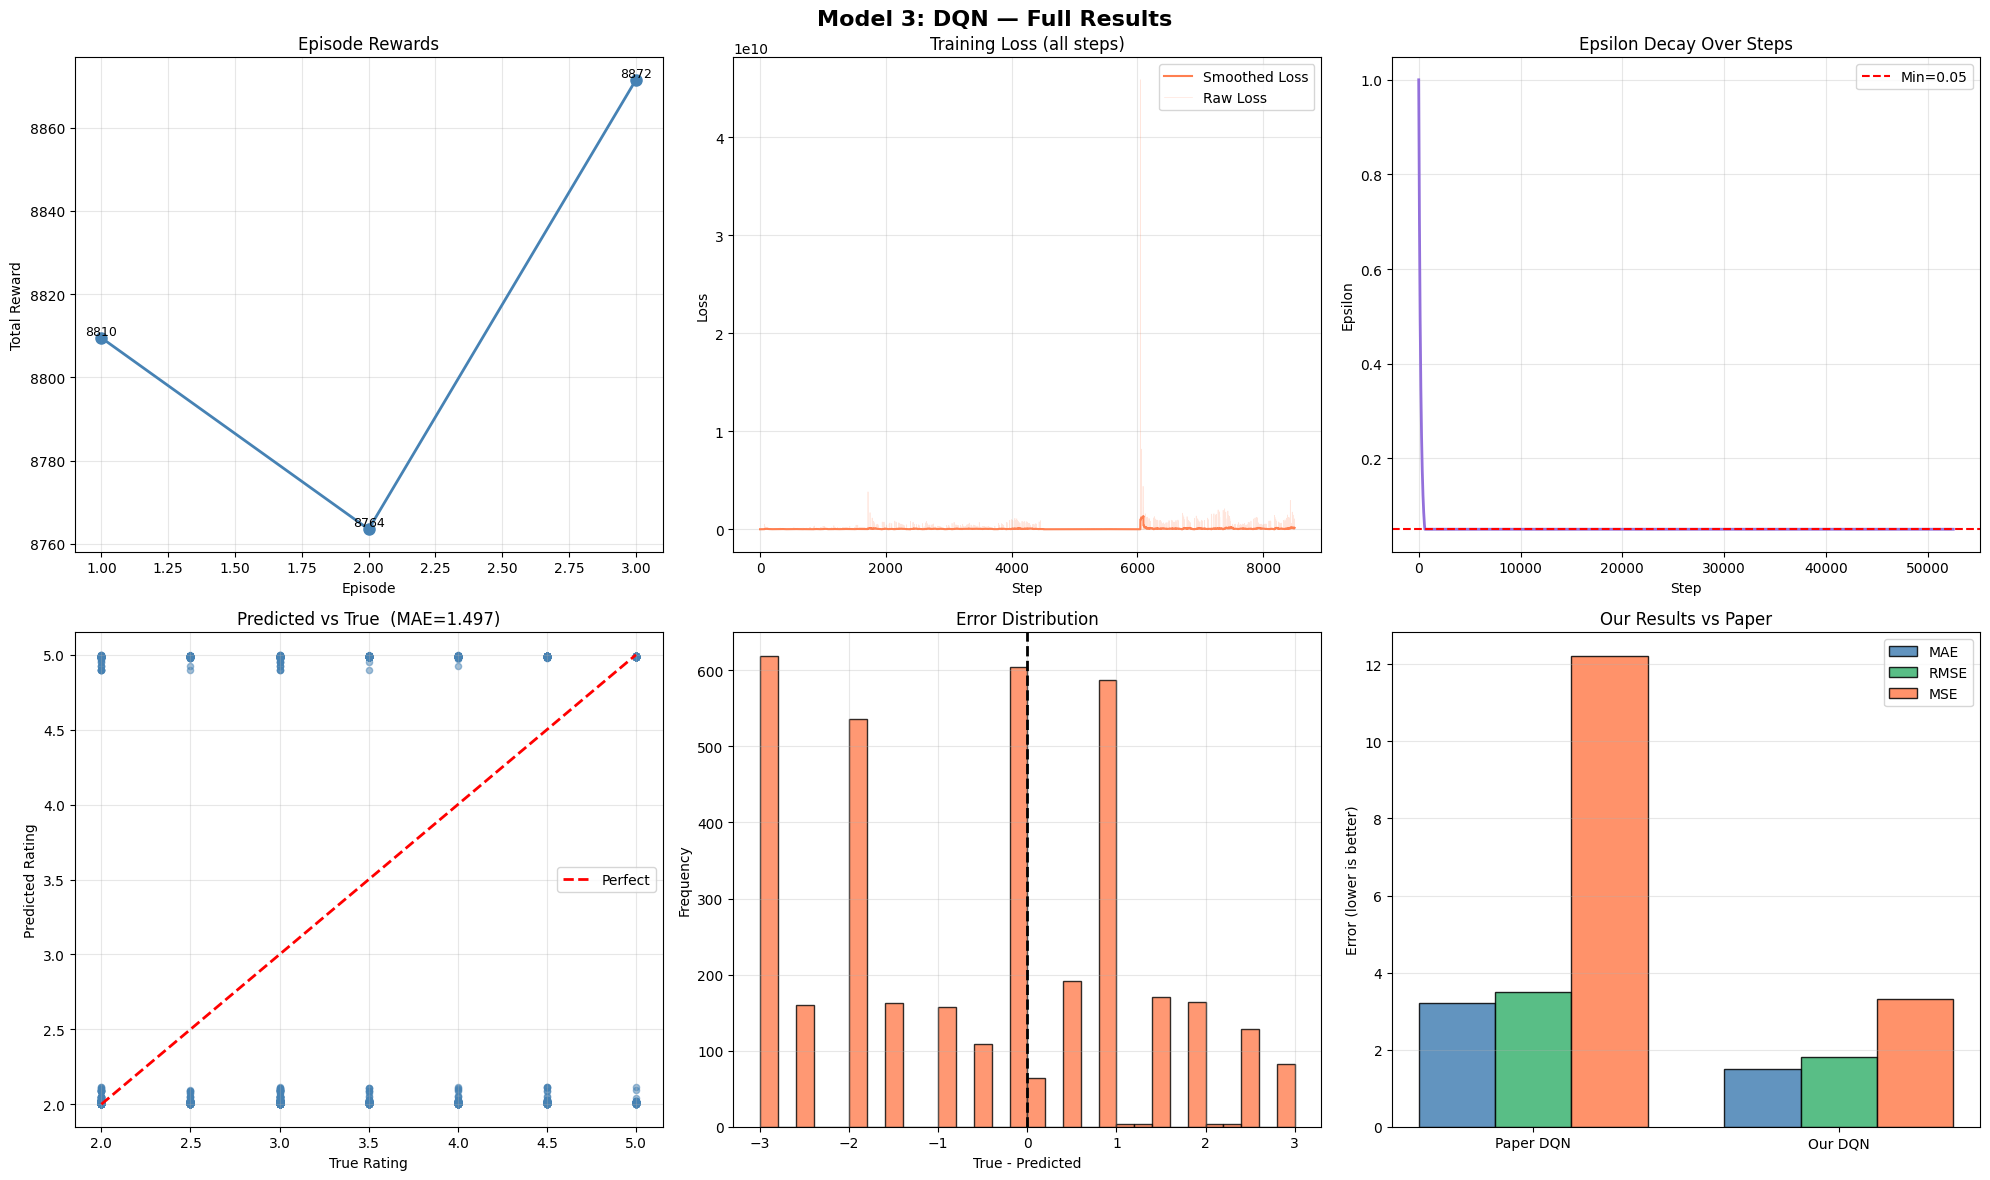


  FINAL SUMMARY — MODEL 3: DQN
  Episodes      : 3
  Total steps   : 9000
  Training time : 0:04:03
  Final epsilon : 0.0500
  Avg reward/ep : 8814.83
  Test MAE      : 1.4968   (paper: 3.22)
  Test MSE      : 3.3036  (paper: 12.22)
  Test RMSE     : 1.8176   (paper: 3.49)
  Beats paper?  : YES


In [22]:
%matplotlib inline

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model 3: DQN — Full Results',
             fontsize=16, fontweight='bold')

# Plot 1: Episode rewards
axes[0,0].plot(range(1, EPISODES+1), episode_rewards,
               color='steelblue', linewidth=2, marker='o', markersize=8)
axes[0,0].set_title('Episode Rewards')
axes[0,0].set_xlabel('Episode')
axes[0,0].set_ylabel('Total Reward')
axes[0,0].grid(True, alpha=0.3)
for i, r in enumerate(episode_rewards):
    axes[0,0].text(i+1, r, f'{r:.0f}',
                   ha='center', va='bottom', fontsize=9)

# Plot 2: Training loss over all steps
if total_loss:
    smooth_loss = pd.Series(total_loss).rolling(window=50, min_periods=1).mean()
    axes[0,1].plot(smooth_loss.values,
                   color='coral', linewidth=1.5, label='Smoothed Loss')
    axes[0,1].plot(total_loss, color='coral',
                   alpha=0.2, linewidth=0.5, label='Raw Loss')
    axes[0,1].set_title('Training Loss (all steps)')
    axes[0,1].set_xlabel('Step')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Epsilon decay
eps_values = [1.0]
e = 1.0
for _ in range(EPISODES * len(train_dqn)):
    e = max(EPSILON_MIN, e * EPSILON_DECAY)
    eps_values.append(e)
axes[0,2].plot(eps_values, color='mediumpurple', linewidth=2)
axes[0,2].set_title('Epsilon Decay Over Steps')
axes[0,2].set_xlabel('Step')
axes[0,2].set_ylabel('Epsilon')
axes[0,2].axhline(EPSILON_MIN, color='red', linestyle='--',
                   linewidth=1.5, label=f'Min={EPSILON_MIN}')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Predicted vs True
axes[1,0].scatter(y_true_dqn, y_pred_dqn,
                  alpha=0.5, s=20, color='steelblue')
axes[1,0].plot([2, 5], [2, 5], 'r--', linewidth=2, label='Perfect')
axes[1,0].set_title(f'Predicted vs True  (MAE={mae_dqn:.3f})')
axes[1,0].set_xlabel('True Rating')
axes[1,0].set_ylabel('Predicted Rating')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Error distribution
errors = y_true_dqn - y_pred_dqn
axes[1,1].hist(errors, bins=30,
               color='coral', edgecolor='black', alpha=0.8)
axes[1,1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1,1].set_title('Error Distribution')
axes[1,1].set_xlabel('True - Predicted')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Our results vs paper
x_pos    = np.arange(2)
w        = 0.25
mae_cmp  = [3.22,  mae_dqn]
mse_cmp  = [12.22, mse_dqn]
rmse_cmp = [3.49,  rmse_dqn]

axes[1,2].bar(x_pos - w, mae_cmp,  width=w, label='MAE',
              color='steelblue',      edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos,     rmse_cmp, width=w, label='RMSE',
              color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos + w, mse_cmp,  width=w, label='MSE',
              color='coral',          edgecolor='black', alpha=0.85)
axes[1,2].set_title('Our Results vs Paper')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(['Paper DQN', 'Our DQN'])
axes[1,2].set_ylabel('Error (lower is better)')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('saved_models/dqn_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*65)
print("  FINAL SUMMARY — MODEL 3: DQN")
print("="*65)
print(f"  Episodes      : {EPISODES}")
print(f"  Total steps   : {step}")
print(f"  Training time : {str(timedelta(seconds=int(training_time_dqn)))}")
print(f"  Final epsilon : {EPSILON:.4f}")
print(f"  Avg reward/ep : {np.mean(episode_rewards):.2f}")
print(f"  Test MAE      : {mae_dqn:.4f}   (paper: 3.22)")
print(f"  Test MSE      : {mse_dqn:.4f}  (paper: 12.22)")
print(f"  Test RMSE     : {rmse_dqn:.4f}   (paper: 3.49)")
print(f"  Beats paper?  : {'YES' if mae_dqn < 3.22 else 'NO'}")
print("="*65)
